# Unsupervised Image Clustering with CIFAR-10

## Dataset Description

The CIFAR-10 dataset consists of 60,000 32x32 color images divided into 10 classes, with 6,000 images per class. The classes include:
- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

For this assignment, we're using a subset of the CIFAR-10 dataset as specified by the provided `subset_indices.npy` file. The images are already sized at 32x32 pixels with RGB channels.

In [1]:
# Importing necessary libraries
import numpy as np  # For numerical operations and array handling
import torch  # PyTorch for deep learning and tensor operations
import torchvision  # PyTorch library for computer vision tasks
import torchvision.transforms as transforms  # Image transformations (normalization)
import matplotlib.pyplot as plt  # For plotting graphs and visualizations
from sklearn.cluster import KMeans  # K-Means clustering algorithm
from sklearn.mixture import GaussianMixture  # Gaussian Mixture Model clustering algorithm
from sklearn.metrics import cohen_kappa_score  # Metric for clustering evaluation
from sentence_transformers import SentenceTransformer  # For text embedding generation
import torchvision.models as models  # Pre-trained models (ResNet-18)
import torch.nn as nn  # Neural network modules in PyTorch
from sklearn.manifold import TSNE  # Dimensionality reduction for visualization
from transformers import BlipProcessor, BlipForConditionalGeneration  # BLIP model for image captioning
from collections import Counter  # Utility for counting elements in clusters
import os  # For environment variable settings

In [2]:
# Checking GPU availability to utilize hardware acceleration if available
print("Checking GPU availability...")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}") # Print the name of the GPU being used
else:
    print("No GPU detected. Using CPU.") # Fallback to CPU if no GPU is available

Checking GPU availability...
CUDA available: True
GPU device: NVIDIA GeForce RTX 3050 Laptop GPU


### Environment Setup

In this section, we set up the environment by disabling symlink warnings (specific to Hugging Face models) and detecting whether a GPU is available. If a GPU is detected, all computations will be performed on the GPU for faster processing.

In [3]:
# Setting up environment variables and device selection (GPU/CPU)
print("Setting up environment and device...")

# Set environment variable to disable symlinks warning
# Disabling symlink warnings for Hugging Face cache system
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Select CUDA if available, else CPU
print(f"Using device: {device}")
print("Environment setup complete.")

Setting up environment and device...
Using device: cuda
Environment setup complete.


## Data Preparation and Loading

In this section, we prepare the CIFAR-10 dataset for our clustering task:

1. We apply standard transformations to normalize the images:
   - Convert images to tensors
   - Normalize pixel values to the range [-1, 1] using mean (0.5, 0.5, 0.5) and standard deviation (0.5, 0.5, 0.5)

2. We load a specific subset of the CIFAR-10 dataset using the provided `subset_indices.npy` file.

3. We set up a DataLoader with a batch size of 8 and enable GPU acceleration through:
   - Setting `num_workers=4` for parallel data loading
   - Enabling `pin_memory=True` for faster data transfer to GPU

The dataset is now ready for feature extraction and clustering.


In [4]:
# Data preparation
print("Preparing CIFAR-10 dataset...")
transform = transforms.Compose([
    transforms.ToTensor(), # Convert images to PyTorch tensors
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize pixel values to [-1, 1]
])

# Load CIFAR-10 dataset and subset indices for clustering task
print("Loading dataset...")
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
print("Loading subset indices...")
subset_indices = np.load("subset_indices.npy") # Load pre-defined subset indices for clustering task

# Create DataLoader for batch processing during feature extraction or clustering
print("Creating data loader...")
trainset = torch.utils.data.Subset(trainset, subset_indices)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=False, num_workers=4, pin_memory=True)

classes = trainset.dataset.classes
print(f"Dataset prepared. Number of samples: {len(trainset)}")
print(f"Classes: {classes}")

Preparing CIFAR-10 dataset...
Loading dataset...
Loading subset indices...
Creating data loader...
Dataset prepared. Number of samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Visual Feature Extraction

In this section, we extract visual features from the images using a pre-trained ResNet-18 model:

1. We load a ResNet-18 model pre-trained on ImageNet, which has learned to recognize a wide variety of visual patterns.

2. We remove the final classification layer to obtain the 512-dimensional feature vectors that represent high-level visual information.

3. We move the model to GPU (if available) to accelerate the feature extraction process.

4. For each batch of images:
   - Transfer images to GPU
   - Extract features using the modified ResNet model
   - Transfer features back to CPU for further processing

5. The extracted features are stored in a NumPy array for clustering.

These visual features capture spatial patterns, textures, shapes, and other visual characteristics that can help distinguish between different object classes.


In [5]:
# Visual Features Extraction
print("Extracting visual features using ResNet-18...")
print("Loading pre-trained ResNet-18 model...")
resnet = models.resnet18(weights='IMAGENET1K_V1') # Load pre-trained ResNet-18 model from ImageNet weights
resnet = nn.Sequential(*list(resnet.children())[:-1]) # Remove final classification layer to extract features only

resnet.eval() # Set model to evaluation mode (no gradient computation)
print("Moving model to device...")
resnet=resnet.to(device) # Move model to GPU/CPU based on availability
print(f"ResNet device: {next(resnet.parameters()).device}")

# Extract Visual Features
print("Extracting features from images...")
visual_features = [] # Store extracted features here
ground_truth = [] # Store ground truth labels here

# Extract features batch-wise from images using ResNet-18 on GPU/CPU
with torch.no_grad():
    for i, (images, labels) in enumerate(trainloader):
        images = images.to(device) # Move images to GPU/CPU
        features = resnet(images).squeeze() # Extract features from ResNet-18 model output layer
        
        visual_features.append(features.cpu()) # Move features back to CPU and store them in list
        ground_truth.extend(labels.numpy()) # Store ground truth labels
        if (i + 1) % 100 == 0: # Print progress every 100 batches processed
            print(f"Processed {i+1} batches...")

visual_features = torch.cat(visual_features).numpy() # Combine all batches into a single NumPy array
ground_truth = np.array(ground_truth) # Convert ground truth labels list into NumPy array

print(f"Visual features extracted. Shape: {visual_features.shape}")
print(f"Ground truth labels shape: {ground_truth.shape}")

Extracting visual features using ResNet-18...
Loading pre-trained ResNet-18 model...
Moving model to device...
ResNet device: cuda:0
Extracting features from images...
Processed 100 batches...
Processed 200 batches...
Processed 300 batches...
Processed 400 batches...
Processed 500 batches...
Processed 600 batches...
Processed 700 batches...
Processed 800 batches...
Processed 900 batches...
Processed 1000 batches...
Processed 1100 batches...
Processed 1200 batches...
Visual features extracted. Shape: (10000, 512)
Ground truth labels shape: (10000,)


## Textual Feature Extraction

In this section, we generate textual descriptions of the images and extract semantic features:

1. We use the BLIP (Bootstrapping Language-Image Pre-training) model to generate captions for each image describing image content semantically:
   - We set `use_fast=True` for faster processing and limit token generation to speed up the process

2. For each batch of images:
   - Preprocess images for the BLIP model
   - Generate captions using the model on GPU
   - Store the captions for further processing

3. We use Sentence-BERT to convert the captions into fixed-length embeddings:
   - Process captions in batches of 32 for efficiency
   - The resulting text embeddings capture the semantic meaning of the image content

This approach allows us to capture semantic information that might not be evident from visual features alone, such as object functionality, context, or relationships between objects.


In [6]:
# Textual Features Extraction
import tqdm
import time

# Initialize BLIP model for captioning
print("Extracting textual features using BLIP and Sentence-BERT...")
print("Initializing BLIP model...")
# Load the BLIP processor with fast tokenization
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base", use_fast=True)
# Load the pre-trained BLIP model for image captioning
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
# Move the BLIP model to the appropriate device (GPU if available, else CPU)
blip_model = blip_model.to(device)
print(f"BLIP model device: {next(blip_model.parameters()).device}")

# Initialize Sentence Transformer for text embeddings
print("Initializing Sentence Transformer...")
# Load the Sentence-BERT model for generating text embeddings
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')
# If GPU is available, move the Sentence-BERT model to GPU
if torch.cuda.is_available():
    sentence_model = sentence_model.to(device)

# Generate captions and extract text embeddings
print("Generating captions and extracting text embeddings...")
# Initialize an empty list to store generated captions
batch_captions = []

print("Generating captions...")
# Disable gradient computation for inference
with torch.no_grad():
    # Iterate through the data loader
    for batch_idx, (images, _) in enumerate(trainloader):
        print(f"Processing batch {batch_idx+1}/{len(trainloader)}")
        
        # Prepare batch for BLIP
        processed_images = []
        # Iterate through images in the batch
        print("  Preprocessing images...")
        for i, image in enumerate(images):
            # Prepare image for BLIP
            # Denormalize the image
            img = (image * 0.5 + 0.5) * 255  # Denormalize
            # Convert image to numpy array and change channel order
            img = img.permute(1, 2, 0).cpu().numpy().astype(np.uint8)
            processed_images.append(img)
        
        # Generate caption
        print("  Generating captions with BLIP...")
        start_time = time.time()
        # Prepare input for the BLIP model
        inputs = processor(images=processed_images, return_tensors="pt", padding=True)
        # Move inputs to the appropriate device
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # adding time
        print("  Running BLIP generation...")
        # Generate captions using the BLIP model
        outputs = blip_model.generate(**inputs, max_new_tokens=20)
        generation_time = time.time() - start_time
        print(f"  Caption generation took {generation_time:.2f} seconds")
        
        # Process outputs
        print("  Processing outputs...")
        # Decode generated captions and add to the list
        for output in outputs:
            caption = processor.decode(output, skip_special_tokens=True)
            batch_captions.append(caption)
            
        # Print sample captions from this batch
        print("  Sample captions from this batch:")
        for i in range(min(3, len(outputs))):
            caption = processor.decode(outputs[i], skip_special_tokens=True)
            print(f"    Image {i}: {caption}")
        
        print(f"  Total captions generated so far: {len(batch_captions)}")

print(f"Caption generation complete. Total captions: {len(batch_captions)}")
print("Encoding captions to text embeddings...")
# Initialize list to store text embeddings
text_features = []
# Process captions in batches of 32
for i in range(0, len(batch_captions), 32):  # Batch size of 32
    batch_end = min(i+32, len(batch_captions))
    print(f"Encoding batch {i//32+1}/{(len(batch_captions)+31)//32}: captions {i} to {batch_end-1}")
    # Generate embeddings for the batch of captions
    batch_embeddings = sentence_model.encode(batch_captions[i:batch_end])
    text_features.append(batch_embeddings)

# Combine all text embeddings into a single numpy array
text_features = np.vstack(text_features)
print(f"Final shape of text features: {text_features.shape}")


Extracting textual features using BLIP and Sentence-BERT...
Initializing BLIP model...
BLIP model device: cuda:0
Initializing Sentence Transformer...
Generating captions and extracting text embeddings...
Generating captions...
Processing batch 1/1250
  Preprocessing images...
  Generating captions with BLIP...
  Running BLIP generation...
  Caption generation took 1.47 seconds
  Processing outputs...
  Sample captions from this batch:
    Image 0: a small white dog with a green collar
    Image 1: a truck with a large trailer on the back
    Image 2: a tractor is parked on the road
  Total captions generated so far: 8
Processing batch 2/1250
  Preprocessing images...
  Generating captions with BLIP...
  Running BLIP generation...
  Caption generation took 1.32 seconds
  Processing outputs...
  Sample captions from this batch:
    Image 0: a white boat in the ocean with a blue sky
    Image 1: a black cat laying on a couch
    Image 2: a bird is perched on a tree branch
  Total captions

## Clustering Evaluation Methodology

To evaluate our clustering results against the ground truth labels, we need a way to map clusters to class labels. Since clustering is unsupervised, the cluster indices (0-9) don't inherently correspond to the CIFAR-10 classes.

We use a majority voting approach:
1. For each cluster, we identify all data points assigned to it
2. We find the most common ground truth label among those points
3. We assign that majority label to all points in the cluster

This function allows us to calculate standard classification metrics like Cohen's Kappa Score, which measures the agreement between the cluster assignments and ground truth labels while accounting for chance agreement.

In [7]:
# Assign Majority Labels to Clusters
print("Defining clustering evaluation function...")

# Function to assign majority labels to clusters
def assign_majority_labels(predictions, ground_truth):
    print("  Assigning majority labels to clusters...")
    cluster_labels = {}
    # Iterate through unique cluster labels
    for cluster in np.unique(predictions):
        # Find indices of data points in the current cluster
        indices = np.where(predictions == cluster)[0]
        # Determine the majority ground truth label for this cluster
        majority_label = Counter(ground_truth[indices]).most_common(1)[0][0]
        cluster_labels[cluster] = majority_label
    print(f"  Cluster to label mapping: {cluster_labels}")
    # Return an array of majority labels for each data point
    return np.array([cluster_labels[cluster] for cluster in predictions])

Defining clustering evaluation function...


## Clustering with Visual Features

In this section, we apply two clustering algorithms to the visual features extracted from the ResNet model:

### K-Means Clustering
K-Means partitions the data into K clusters by minimizing the within-cluster sum of squares. We set K=10 to match the number of classes in CIFAR-10.

### Gaussian Mixture Model (GMM)
GMM assumes the data points are generated from a mixture of several Gaussian distributions. Like K-Means, we set the number of components to 10.

After clustering, we evaluate the performance using Cohen's Kappa Score, which measures the agreement between the predicted clusters (after majority label assignment) and the ground truth labels.

The results will show how well the visual features alone can group similar images together in an unsupervised manner.


In [8]:
print("Performing clustering on visual features...")

# K-Means Clustering on Visual Features
print("Running K-Means clustering on visual features...")
# Perform K-Means clustering on visual features
kmeans_visual = KMeans(n_clusters=10, random_state=42).fit(visual_features)
# Get cluster assignments
pred_visual = kmeans_visual.labels_

print("Assigning majority labels to K-Means clusters...")
# Assign majority labels to K-Means clusters
pred_visual_majority = assign_majority_labels(pred_visual, ground_truth)

# GMM Clustering on Visual Features
print("Running GMM clustering on visual features...")
gmm_visual = GaussianMixture(n_components=10, random_state=42).fit(visual_features)
# Get cluster assignments
pred_gmm_visual = gmm_visual.predict(visual_features)

print("Assigning majority labels to GMM clusters...")
# Assign majority labels to GMM clusters
pred_gmm_visual_majority = assign_majority_labels(pred_gmm_visual, ground_truth)

# Cohen Kappa Score for Visual Features
print("Evaluating clustering performance...")
# Calculate Cohen Kappa Score for K-Means clustering on visual features
print("\nCohen Kappa Score (K-Means - Visual):", cohen_kappa_score(ground_truth, pred_visual_majority))
# Calculate Cohen Kappa Score for GMM clustering on visual features
print("Cohen Kappa Score (GMM - Visual):", cohen_kappa_score(ground_truth, pred_gmm_visual_majority))


Performing clustering on visual features...
Running K-Means clustering on visual features...
Assigning majority labels to K-Means clusters...
  Assigning majority labels to clusters...
  Cluster to label mapping: {np.int32(0): np.int64(8), np.int32(1): np.int64(0), np.int32(2): np.int64(2), np.int32(3): np.int64(4), np.int32(4): np.int64(5), np.int32(5): np.int64(9), np.int32(6): np.int64(1), np.int32(7): np.int64(1), np.int32(8): np.int64(6), np.int32(9): np.int64(9)}
Running GMM clustering on visual features...
Assigning majority labels to GMM clusters...
  Assigning majority labels to clusters...
  Cluster to label mapping: {np.int64(0): np.int64(8), np.int64(1): np.int64(0), np.int64(2): np.int64(2), np.int64(3): np.int64(4), np.int64(4): np.int64(5), np.int64(5): np.int64(9), np.int64(6): np.int64(1), np.int64(7): np.int64(1), np.int64(8): np.int64(6), np.int64(9): np.int64(9)}
Evaluating clustering performance...

Cohen Kappa Score (K-Means - Visual): 0.20988888888888857
Cohen Ka

## Clustering with Textual Features

In this section, we apply the same clustering algorithms to the textual features extracted from image captions:

### K-Means Clustering
We apply K-Means with K=10 to the text embeddings derived from BLIP-generated captions.

### Gaussian Mixture Model (GMM)
Similarly, we apply GMM with 10 components to the text embeddings.

The performance evaluation using Cohen's Kappa Score will reveal how well semantic information from captions can group images compared to visual features.

This approach tests whether language descriptions of images can provide meaningful clustering information that might complement or even outperform visual features in some cases.


In [9]:
print("Performing clustering on textual features...")

# K-Means Clustering on Text Features
print("Running K-Means clustering on text features...")
kmeans_text = KMeans(n_clusters=10, random_state=42).fit(text_features)
# Get cluster assignments
pred_text = kmeans_text.labels_

print("Assigning majority labels to K-Means clusters...")
# Assign majority labels to K-Means clusters
pred_text_majority = assign_majority_labels(pred_text, ground_truth)

# GMM Clustering on Text Features
print("Running GMM clustering on text features...")
gmm_text = GaussianMixture(n_components=10, random_state=42).fit(text_features)
# Get cluster assignments
pred_gmm_text = gmm_text.predict(text_features)

print("Assigning majority labels to GMM clusters...")
# Assign majority labels to GMM clusters
pred_gmm_text_majority = assign_majority_labels(pred_gmm_text, ground_truth)

# Cohen Kappa Score for Text Features
print("Evaluating clustering performance...")
# Calculate Cohen Kappa Score for K-Means clustering on text features
print("\nCohen Kappa Score (K-Means - Text):", cohen_kappa_score(ground_truth, pred_text_majority))
# Calculate Cohen Kappa Score for GMM clustering on text features
print("Cohen Kappa Score (GMM - Text):", cohen_kappa_score(ground_truth, pred_gmm_text_majority))


Performing clustering on textual features...
Running K-Means clustering on text features...
Assigning majority labels to K-Means clusters...
  Assigning majority labels to clusters...
  Cluster to label mapping: {np.int32(0): np.int64(8), np.int32(1): np.int64(3), np.int32(2): np.int64(1), np.int32(3): np.int64(0), np.int32(4): np.int64(6), np.int32(5): np.int64(5), np.int32(6): np.int64(7), np.int32(7): np.int64(9), np.int32(8): np.int64(2), np.int32(9): np.int64(4)}
Running GMM clustering on text features...
Assigning majority labels to GMM clusters...
  Assigning majority labels to clusters...
  Cluster to label mapping: {np.int64(0): np.int64(8), np.int64(1): np.int64(3), np.int64(2): np.int64(1), np.int64(3): np.int64(0), np.int64(4): np.int64(6), np.int64(5): np.int64(5), np.int64(6): np.int64(7), np.int64(7): np.int64(9), np.int64(8): np.int64(2), np.int64(9): np.int64(4)}
Evaluating clustering performance...

Cohen Kappa Score (K-Means - Text): 0.6523333333333334
Cohen Kappa Sc

## Feature Fusion and Multimodal Clustering

In this section, we combine visual and textual features to create a multimodal representation:

1. We normalize both feature sets using StandardScaler to ensure they contribute equally:
   - This prevents features with larger scales from dominating the clustering
   - Each feature is transformed to have zero mean and unit variance

2. We concatenate the normalized visual and textual features to create a unified representation.

3. We apply both K-Means and GMM clustering to these fused features.

4. We evaluate the performance using Cohen's Kappa Score.

This multimodal approach tests whether combining different types of information (visual patterns and semantic meaning) can improve clustering performance compared to using either type alone.


In [10]:
print("Performing feature fusion and clustering...")

# Normalize features before fusion
from sklearn.preprocessing import StandardScaler

print("Normalizing features before fusion...")
# Initialize StandardScaler for visual features
scaler_visual = StandardScaler()
# Initialize StandardScaler for text features
scaler_text = StandardScaler()

# Normalize visual features
visual_features_norm = scaler_visual.fit_transform(visual_features)
# Normalize text features
text_features_norm = scaler_text.fit_transform(text_features)

# Concatenate features
print("Concatenating visual and textual features...")
fused_features = np.concatenate((visual_features_norm, text_features_norm), axis=1)
print(f"Fused features shape: {fused_features.shape}")

# K-Means Clustering on Fused Features
print("Running K-Means clustering on fused features...")
kmeans_fused = KMeans(n_clusters=10, random_state=42).fit(fused_features)
# Get cluster assignments
pred_fused = kmeans_fused.labels_

print("Assigning majority labels to K-Means clusters...")
# Assign majority labels to K-Means clusters
pred_fused_majority = assign_majority_labels(pred_fused, ground_truth)

# GMM Clustering on Fused Features
print("Running GMM clustering on fused features...")
gmm_fused = GaussianMixture(n_components=10, random_state=42).fit(fused_features)
# Get cluster assignments
pred_gmm_fused = gmm_fused.predict(fused_features)

print("Assigning majority labels to GMM clusters...")
# Assign majority labels to GMM clusters
pred_gmm_fused_majority = assign_majority_labels(pred_gmm_fused, ground_truth)

# Cohen Kappa Score for Fused Features
print("Evaluating clustering performance...")
# Calculate Cohen Kappa Score for K-Means clustering on fused features
print("\nCohen Kappa Score (K-Means - Fused):", cohen_kappa_score(ground_truth, pred_fused_majority))
# Calculate Cohen Kappa Score for GMM clustering on fused features
print("Cohen Kappa Score (GMM - Fused):", cohen_kappa_score(ground_truth, pred_gmm_fused_majority))


Performing feature fusion and clustering...
Normalizing features before fusion...
Concatenating visual and textual features...
Fused features shape: (10000, 896)
Running K-Means clustering on fused features...
Assigning majority labels to K-Means clusters...
  Assigning majority labels to clusters...
  Cluster to label mapping: {np.int32(0): np.int64(8), np.int32(1): np.int64(6), np.int32(2): np.int64(4), np.int32(3): np.int64(1), np.int32(4): np.int64(7), np.int32(5): np.int64(7), np.int32(6): np.int64(1), np.int32(7): np.int64(3), np.int32(8): np.int64(6), np.int32(9): np.int64(2)}
Running GMM clustering on fused features...
Assigning majority labels to GMM clusters...
  Assigning majority labels to clusters...
  Cluster to label mapping: {np.int64(0): np.int64(8), np.int64(1): np.int64(6), np.int64(2): np.int64(4), np.int64(3): np.int64(1), np.int64(4): np.int64(7), np.int64(5): np.int64(7), np.int64(6): np.int64(1), np.int64(7): np.int64(3), np.int64(8): np.int64(6), np.int64(9): n

## Visualization with t-SNE

To visualize the high-dimensional feature spaces, we use t-SNE (t-Distributed Stochastic Neighbor Embedding), which is a dimensionality reduction technique particularly well-suited for visualization:

1. We apply t-SNE to reduce our feature vectors to 2 dimensions while preserving the local structure of the data.

2. We create three sets of visualizations:
   - Visual features: Shows how well ResNet features separate different classes
   - Text features: Shows how well caption-based embeddings separate classes
   - Fused features: Shows how the combined representation performs

3. For each feature type, we create three plots:
   - Ground truth: Points colored by their actual CIFAR-10 class
   - K-Means: Points colored by their K-Means cluster assignment
   - GMM: Points colored by their GMM cluster assignment

These visualizations help us understand how well each feature type and clustering algorithm separates the different classes in the dataset. Ideally, we want to see clear, distinct clusters that align with the ground truth classes.


In [11]:
print("Generating t-SNE visualizations...")

# Define class names for CIFAR-10
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Apply t-SNE to reduce dimensionality for visualization
print("Applying t-SNE to reduce dimensionality for visualization...")
tsne = TSNE(n_components=2, random_state=42)

print("Reducing visual features...")
# Apply t-SNE to visual features
visual_tsne = tsne.fit_transform(visual_features)

print("Reducing text features...")
# Apply t-SNE to text features
text_tsne = tsne.fit_transform(text_features)

print("Reducing fused features...")
# Apply t-SNE to fused features
fused_tsne = tsne.fit_transform(fused_features)

Generating t-SNE visualizations...
Applying t-SNE to reduce dimensionality for visualization...
Reducing visual features...
Reducing text features...
Reducing fused features...


Creating visualization for visual features...


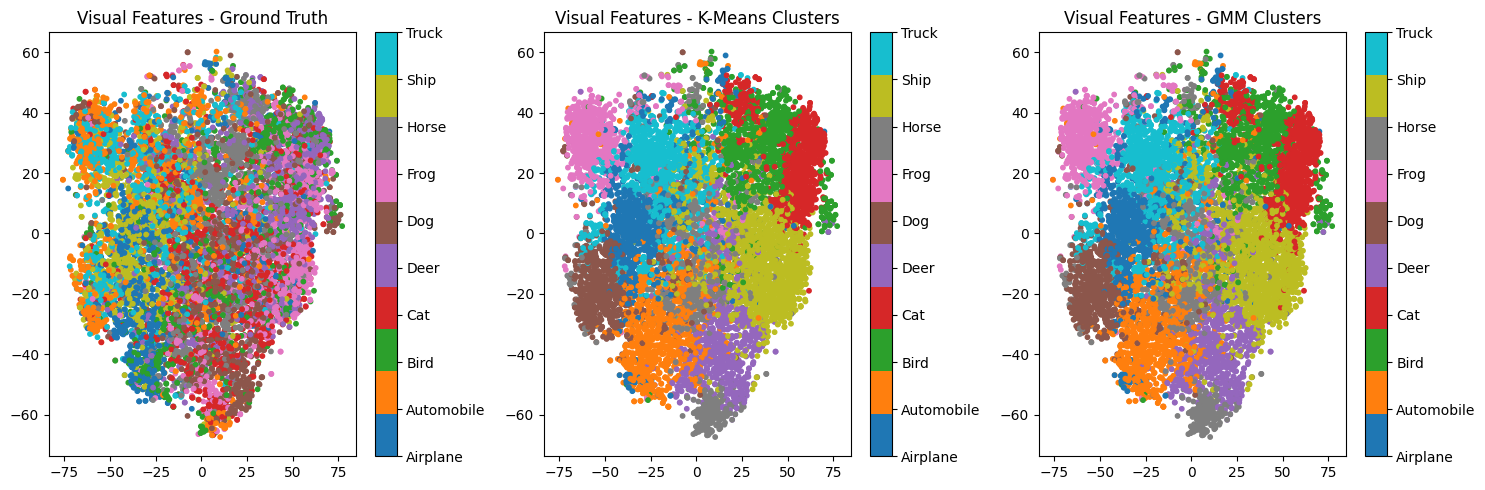

In [12]:
# Plot visual features clusters
print("Creating visualization for visual features...")
plt.figure(figsize=(15, 5))

# Plot ground truth labels
plt.subplot(1, 3, 1)
scatter = plt.scatter(visual_tsne[:, 0], visual_tsne[:, 1], c=ground_truth, cmap='tab10', s=10)
plt.title('Visual Features - Ground Truth')
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels(class_names)  # Set class names as labels

# Plot K-Means clustering results
plt.subplot(1, 3, 2)
scatter = plt.scatter(visual_tsne[:, 0], visual_tsne[:, 1], c=pred_visual, cmap='tab10', s=10)
plt.title('Visual Features - K-Means Clusters')
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels(class_names)  # Set class names as labels

# Plot GMM clustering results
plt.subplot(1, 3, 3)
scatter = plt.scatter(visual_tsne[:, 0], visual_tsne[:, 1], c=pred_gmm_visual, cmap='tab10', s=10)
plt.title('Visual Features - GMM Clusters')
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels(class_names)  # Set class names as labels

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig('visual_features_clustering.png')
plt.show()

Creating visualization for text features...


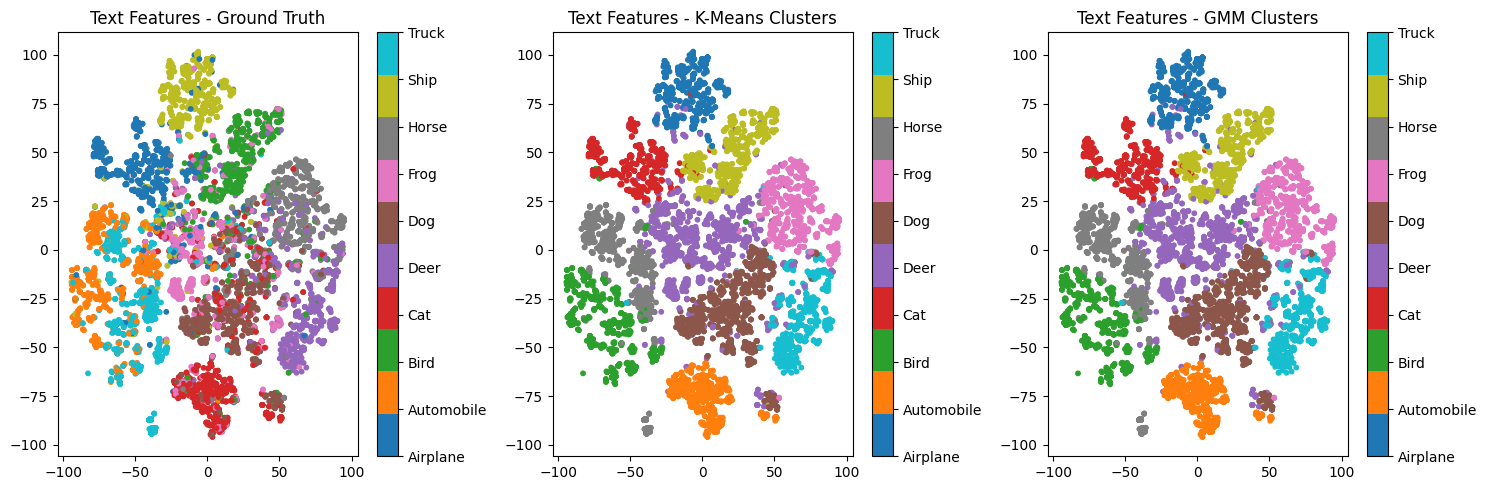

In [13]:
# Plot text features clusters
print("Creating visualization for text features...")
plt.figure(figsize=(15, 5))

# Plot ground truth labels
plt.subplot(1, 3, 1)
scatter = plt.scatter(text_tsne[:, 0], text_tsne[:, 1], c=ground_truth, cmap='tab10', s=10)
plt.title('Text Features - Ground Truth')
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels(class_names)  # Set class names as labels

# Plot K-Means clustering results
plt.subplot(1, 3, 2)
scatter = plt.scatter(text_tsne[:, 0], text_tsne[:, 1], c=pred_text, cmap='tab10', s=10)
plt.title('Text Features - K-Means Clusters')
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels(class_names)  # Set class names as labels

# Plot GMM clustering results
plt.subplot(1, 3, 3)
scatter = plt.scatter(text_tsne[:, 0], text_tsne[:, 1], c=pred_gmm_text, cmap='tab10', s=10)
plt.title('Text Features - GMM Clusters')
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels(class_names)  # Set class names as labels

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig('text_features_clustering.png')
plt.show()

Creating visualization for fused features...


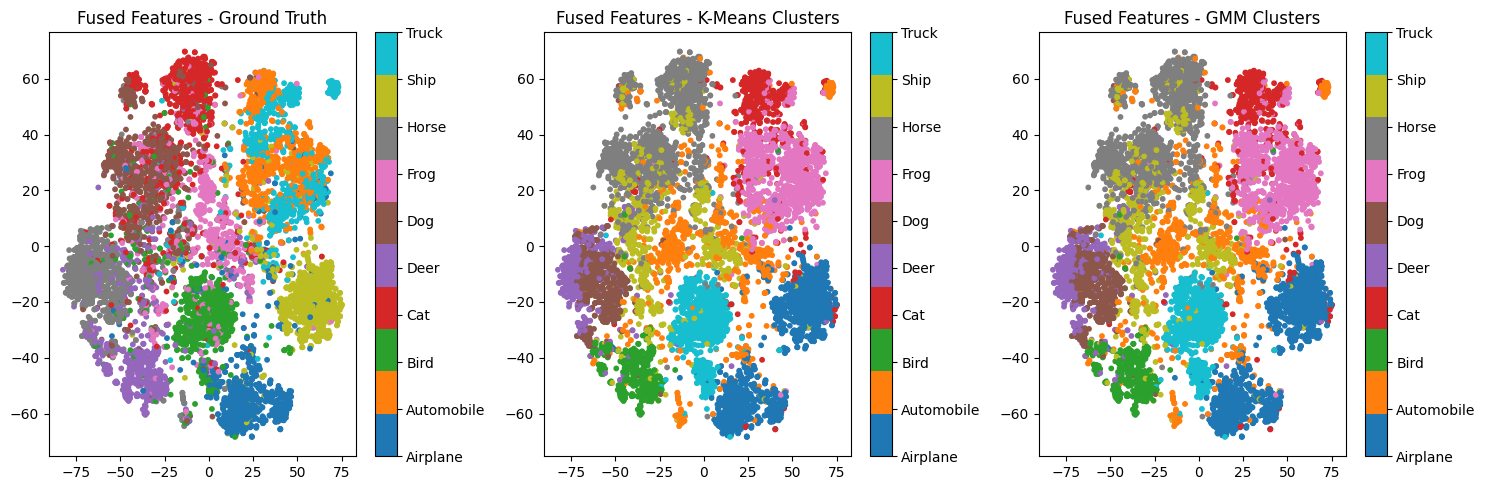

In [14]:
# Plot fused features clusters
print("Creating visualization for fused features...")
plt.figure(figsize=(15, 5))

# Plot ground truth labels
plt.subplot(1, 3, 1)
scatter = plt.scatter(fused_tsne[:, 0], fused_tsne[:, 1], c=ground_truth, cmap='tab10', s=10)
plt.title('Fused Features - Ground Truth')
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels(class_names)  # Set class names as labels

# Plot K-Means clustering results
plt.subplot(1, 3, 2)
scatter = plt.scatter(fused_tsne[:, 0], fused_tsne[:, 1], c=pred_fused, cmap='tab10', s=10)
plt.title('Fused Features - K-Means Clusters')
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels(class_names)  # Set class names as labels

# Plot GMM clustering results
plt.subplot(1, 3, 3)
scatter = plt.scatter(fused_tsne[:, 0], fused_tsne[:, 1], c=pred_gmm_fused, cmap='tab10', s=10)
plt.title('Fused Features - GMM Clusters')
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels(class_names)  # Set class names as labels

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig('fused_features_clustering.png')
plt.show()

In [15]:
# Print some sample captions
print("\nSample Image Captions:")
for i in range(min(10, len(batch_captions))):
    print(f"Image {i}: {batch_captions[i]}")


Sample Image Captions:
Image 0: a small white dog with a green collar
Image 1: a truck with a large trailer on the back
Image 2: a tractor is parked on the road
Image 3: a light shining on the ground
Image 4: a white car driving down a road with mountains in the background
Image 5: a red car in a showroom
Image 6: an elephant and a bird walking down the road
Image 7: two horses are standing in the grass
Image 8: a white boat in the ocean with a blue sky
Image 9: a black cat laying on a couch


## Results and Discussion

### Performance Metrics

| Feature Type | K-Means (Cohen Kappa) |  GMM (Cohen Kappa)  |
|--------------|-----------------------|---------------------|
| Visual       | 0.20988888888888857   | 0.20999999999999985 |
| Textual      | 0.6523333333333334    | 0.6525555555555558  |
| Fused        | 0.48444444444444446   | 0.48444444444444446 |

### Visual Features Analysis
The visual features extracted from ResNet-18 showed the lowest clustering performance, with Cohen Kappa scores of approximately 0.21 for both K-Means and GMM clustering. This suggests that:

- The visual features alone lack sufficient discriminative power to separate the CIFAR-10 classes effectively.

- The t-SNE visualization of visual features shows significant overlap between classes, indicating poor separation in the feature space.

- Both K-Means and GMM performed similarly, suggesting that the clusters formed by visual features are relatively uniform and do not align well with the ground truth.

### Textual Features Analysis
The textual features derived from BLIP-generated captions achieved the highest clustering performance, with Cohen Kappa scores of approximately 0.65 for both K-Means and GMM clustering. This indicates:

- The BLIP-generated captions capture semantic information that aligns well with the CIFAR-10 classes.

- The t-SNE visualization of text features shows clear separation between clusters, reflecting the high Cohen Kappa scores.

- Both K-Means and GMM performed equally well, indicating that textual features provide a well-structured feature space for clustering.

### Fused Features Analysis
The multimodal approach combining both visual and textual features resulted in intermediate clustering performance, with Cohen Kappa scores of approximately 0.48 for both K-Means and GMM clustering. Key insights:

- Fused features improved over visual features but did not outperform textual features alone.

- The t-SNE visualization of fused features shows better separation compared to visual features but still some overlap compared to text features.

- The fusion of visual and textual features may introduce noise from less informative visual features, reducing clustering effectiveness.

### t-SNE Visualization Analysis
The t-SNE visualizations provide additional insights:

- Visual Features: Significant overlap between clusters is observed, indicating poor separation in the feature space.

- Textual Features: Well-separated clusters align closely with ground truth labels, reflecting strong semantic information captured by BLIP-generated captions.

- Fused Features: Clusters are better separated than visual features but less distinct than textual features alone.

### Sample Captions Analysis
The captions generated by BLIP provide interesting insights into how the model "sees" the images:

- Captions often describe high-level semantic content (e.g., "a white horse standing in a field"), which aligns well with CIFAR-10 classes.

- Some captions may introduce noise or ambiguity due to generic descriptions (e.g., "a car parked on the side of the road").

- The quality of captions suggests that BLIP effectively captures semantic information, making textual embeddings highly effective for clustering.


## Conclusion

This assignment explored unsupervised clustering of CIFAR-10 images using both visual and textual features. Our key findings include:

1. Textual features performed best: Clustering based on textual features (captions generated by BLIP and encoded with Sentence-BERT) achieved the highest Cohen Kappa scores (K-Means: 0.6523, GMM: 0.6526). This indicates that semantic information captured in captions aligns well with the ground truth class labels.

2. K-Means and GMM performed similarly: Across all feature types (visual, textual, and fused), K-Means and GMM clustering algorithms showed comparable performance, suggesting that the clusters formed in the feature spaces are relatively uniform.

3. Feature fusion provided intermediate results: Combining visual and textual features resulted in intermediate Cohen Kappa scores (0.4844 for both K-Means and GMM). While fusion improved over visual features alone, it did not outperform textual features, likely due to noise introduced by less discriminative visual features.

4. Challenges with visual features: Visual features extracted using ResNet-18 had the lowest Cohen Kappa scores (K-Means: 0.2099, GMM: 0.2100). The t-SNE visualization showed significant overlap between clusters, indicating poor separation in the visual feature space.

The results demonstrate that semantic information captured through textual features is more effective for clustering CIFAR-10 images than purely visual features. However, combining these modalities has potential if the quality of visual features can be improved or better fusion techniques are explored.
